# Inception: Multi-Scale Efficiency (and the Path to ResNet)

## Introduction

**Inception (GoogLeNet)** (Szegedy et al., 2014) asked a fundamental question: **"What filter size should we use?"** Answer: **"All of them!"**

Instead of choosing between filter sizes, Inception runs them **in parallel** and lets the network learn which matters where.

**Core innovations:**

1. **Inception module** - Parallel 1×1, 3×3, 5×5 convs + pooling
2. **1×1 bottleneck layers** - Dimensionality reduction before expensive ops
3. **Global Average Pooling** - Eliminates FC layers entirely
4. **Auxiliary classifiers** - Helps gradient flow in deep networks

**What we'll explore:**

- Why multi-scale parallel extraction is more efficient than uniform depth
- How 1×1 convolutions dramatically reduce computation
- Train Inception on CIFAR-10 and compare to VGG
- **Understand the remaining problem that ResNet solved**

**Why this matters:**

Inception proved that **architectural efficiency matters** - you don't need massive parameters to get great performance. But even Inception couldn't go arbitrarily deep. That limitation led to the next revolution: **residual connections**.

## 1. Setup

### Import libraries

### Set random seed for reproducibility

In [ ]:
from aiml_notebooks import get_device, set_seed

In [2]:
set_seed(42)

### Configure device

In [3]:
device = get_device()
print(f"Using device: {device}")

Using CUDA GPU: NVIDIA GeForce RTX 4090
Using device: cuda


## 2. Recap: VGG's Limitations

Before diving into Inception, let's recall what we need to solve:

| VGG Problem | Impact |
|-------------|--------|
| **FC layers dominate** | 90% of params in original VGG-16 |
| **Single-scale features** | All layers use 3×3, no multi-scale |
| **Uniform computation** | Same depth everywhere, wasteful |
| **Massive parameters** | VGG-16: 138M params |

Inception addresses **all four** with elegant architectural innovations.

## 3. Inception's Key Innovations

### Innovation 1: Multi-Scale Parallel Extraction

Instead of choosing one filter size, run multiple sizes in parallel.

In [4]:
print("Multi-Scale Reasoning:\n")
print("Natural images have features at different scales:")
print("  • Small details: eyes, text, edges → Need 1×1, 3×3 filters")
print("  • Medium objects: faces, cars → Need 3×3, 5×5 filters")
print("  • Large regions: sky, background → Need 5×5, pooling")
print("\nVGG's approach:")
print("  ❌ Force all features through same 3×3 pipeline")
print("  ❌ Stack many layers to build large receptive fields")
print("  ❌ Computationally expensive")
print("\nInception's approach:")
print("  ✅ Run 1×1, 3×3, 5×5 in parallel")
print("  ✅ Concatenate outputs (multi-scale features)")
print("  ✅ Let network learn which scale matters where")
print("  ✅ More efficient than brute-force depth")

Multi-Scale Reasoning:

Natural images have features at different scales:
  • Small details: eyes, text, edges → Need 1×1, 3×3 filters
  • Medium objects: faces, cars → Need 3×3, 5×5 filters
  • Large regions: sky, background → Need 5×5, pooling

VGG's approach:
  ❌ Force all features through same 3×3 pipeline
  ❌ Stack many layers to build large receptive fields
  ❌ Computationally expensive

Inception's approach:
  ✅ Run 1×1, 3×3, 5×5 in parallel
  ✅ Concatenate outputs (multi-scale features)
  ✅ Let network learn which scale matters where
  ✅ More efficient than brute-force depth


### Innovation 2: 1×1 Convolutions (Bottleneck Layers)

Running parallel convolutions is expensive. 1×1 convs reduce dimensionality first.

In [5]:
print("The 1×1 Convolution Trick:\n")
print("Problem: Parallel convolutions multiply parameters")
print("  Example: 512 input channels → 512 output channels")
print("  Direct 5×5 conv: 512 × 512 × 5 × 5 = 6,553,600 params")
print("\nSolution: Bottleneck with 1×1 convs")
print("  1×1 conv (512 → 64): 512 × 64 × 1 × 1 = 32,768 params")
print("  5×5 conv (64 → 64):  64 × 64 × 5 × 5 = 102,400 params")
print("  1×1 conv (64 → 512): 64 × 512 × 1 × 1 = 32,768 params")
print("  Total: 167,936 params (97% reduction!)")
print("\n💡 1×1 convolutions:")
print("  • Act as learnable dimensionality reduction")
print("  • Add extra non-linearity (ReLU after each)")
print("  • Enable cross-channel information mixing")
print("  • Make large filters computationally feasible")

The 1×1 Convolution Trick:

Problem: Parallel convolutions multiply parameters
  Example: 512 input channels → 512 output channels
  Direct 5×5 conv: 512 × 512 × 5 × 5 = 6,553,600 params

Solution: Bottleneck with 1×1 convs
  1×1 conv (512 → 64): 512 × 64 × 1 × 1 = 32,768 params
  5×5 conv (64 → 64):  64 × 64 × 5 × 5 = 102,400 params
  1×1 conv (64 → 512): 64 × 512 × 1 × 1 = 32,768 params
  Total: 167,936 params (97% reduction!)

💡 1×1 convolutions:
  • Act as learnable dimensionality reduction
  • Add extra non-linearity (ReLU after each)
  • Enable cross-channel information mixing
  • Make large filters computationally feasible


### Visualize the Inception module

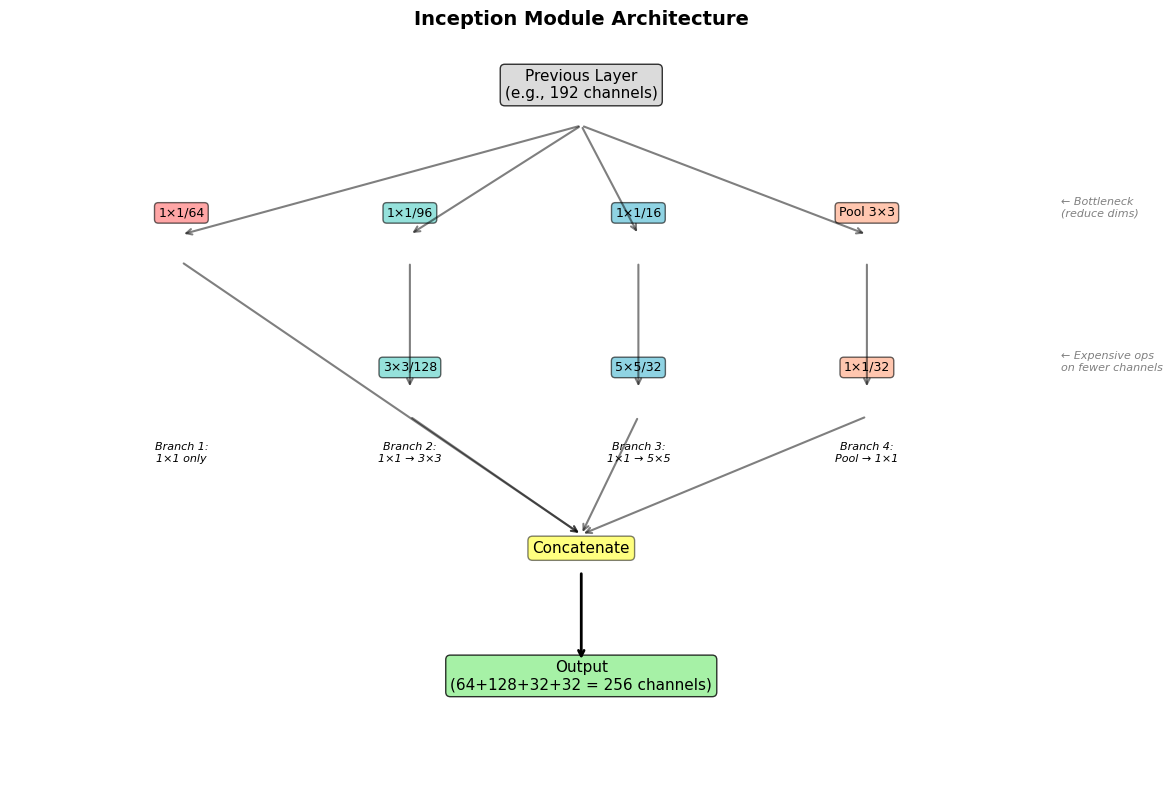


✅ Key insight: Use 1×1 bottleneck to reduce channels before expensive 3×3 and 5×5 ops!


In [6]:
# Create a diagram of the Inception module
fig, ax = plt.subplots(figsize=(12, 8))

# Input
ax.text(0.5, 0.95, 'Previous Layer\n(e.g., 192 channels)', ha='center', fontsize=11,
        bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))

# 1×1 reduction layer
y_reduce = 0.82
branches = [
    (0.15, '1×1/64', '#FF6B6B'),
    (0.35, '1×1/96', '#4ECDC4'),
    (0.55, '1×1/16', '#45B7D1'),
    (0.75, 'Pool 3×3', '#FFA07A')
]

for x, label, color in branches:
    ax.text(x, y_reduce, label, ha='center', fontsize=9,
            bbox=dict(boxstyle='round', facecolor=color, alpha=0.6))
    ax.annotate('', xy=(x, y_reduce-0.02), xytext=(0.5, 0.92),
                arrowprops=dict(arrowstyle='->', lw=1.5, alpha=0.5))

# Main convolutions
y_main = 0.65
main_ops = [
    (0.15, '(output)', '#FF6B6B'),
    (0.35, '3×3/128', '#4ECDC4'),
    (0.55, '5×5/32', '#45B7D1'),
    (0.75, '1×1/32', '#FFA07A')
]

for i, (x, label, color) in enumerate(main_ops):
    if i > 0:  # Skip first branch (no op after 1×1)
        ax.text(x, y_main, label, ha='center', fontsize=9,
                bbox=dict(boxstyle='round', facecolor=color, alpha=0.6))
        ax.annotate('', xy=(x, y_main-0.02), xytext=(x, y_reduce-0.05),
                    arrowprops=dict(arrowstyle='->', lw=1.5, alpha=0.5))

# Annotations for bottleneck
ax.text(0.92, y_reduce, '← Bottleneck\n(reduce dims)', ha='left', fontsize=8, 
        style='italic', color='gray')
ax.text(0.92, y_main, '← Expensive ops\non fewer channels', ha='left', fontsize=8,
        style='italic', color='gray')

# Concatenation
y_concat = 0.45
ax.text(0.5, y_concat, 'Concatenate', ha='center', fontsize=11,
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

for x, _, _ in main_ops:
    y_from = y_main - 0.05 if x != 0.15 else y_reduce - 0.05
    ax.annotate('', xy=(0.5, y_concat+0.02), xytext=(x, y_from),
                arrowprops=dict(arrowstyle='->', lw=1.5, alpha=0.5))

# Output
ax.text(0.5, 0.30, 'Output\n(64+128+32+32 = 256 channels)', ha='center', fontsize=11,
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))
ax.annotate('', xy=(0.5, 0.33), xytext=(0.5, y_concat-0.02),
            arrowprops=dict(arrowstyle='->', lw=2))

# Labels
ax.text(0.15, 0.55, 'Branch 1:\n1×1 only', ha='center', fontsize=8, style='italic')
ax.text(0.35, 0.55, 'Branch 2:\n1×1 → 3×3', ha='center', fontsize=8, style='italic')
ax.text(0.55, 0.55, 'Branch 3:\n1×1 → 5×5', ha='center', fontsize=8, style='italic')
ax.text(0.75, 0.55, 'Branch 4:\nPool → 1×1', ha='center', fontsize=8, style='italic')

ax.set_xlim(0, 1)
ax.set_ylim(0.2, 1)
ax.axis('off')
ax.set_title('Inception Module Architecture', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print("\n✅ Key insight: Use 1×1 bottleneck to reduce channels before expensive 3×3 and 5×5 ops!")

## 4. Dataset Preparation

### Define data transforms

In [ ]:
from torchvision import datasets, transforms

In [7]:
# CIFAR-10 normalization statistics
mean = (0.4914, 0.4822, 0.4465)
std = (0.2023, 0.1994, 0.2010)

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

### Load CIFAR-10 dataset

In [8]:
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Training samples: 50000
Test samples: 10000


### Create data loaders

In [ ]:
from torch.utils.data import DataLoader

In [9]:
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

## 5. Inception Architecture

### Inception Module

The core building block with parallel convolutions and 1×1 bottlenecks.

In [10]:
class InceptionModule(nn.Module):
    """Inception module with dimension reduction.
    
    Args:
        in_channels: Input channels
        out_1x1: Output channels for 1×1 conv branch
        red_3x3: Reduction channels before 3×3 conv
        out_3x3: Output channels for 3×3 conv branch
        red_5x5: Reduction channels before 5×5 conv
        out_5x5: Output channels for 5×5 conv branch
        out_pool: Output channels for pool projection branch
    """
    def __init__(self, in_channels, out_1x1, red_3x3, out_3x3, red_5x5, out_5x5, out_pool):
        super().__init__()
        
        # Branch 1: 1×1 conv only
        self.branch1 = nn.Sequential(
            nn.Conv2d(in_channels, out_1x1, kernel_size=1),
            nn.BatchNorm2d(out_1x1),
            nn.ReLU(inplace=True),
        )
        
        # Branch 2: 1×1 reduction → 3×3 conv
        self.branch2 = nn.Sequential(
            nn.Conv2d(in_channels, red_3x3, kernel_size=1),
            nn.BatchNorm2d(red_3x3),
            nn.ReLU(inplace=True),
            nn.Conv2d(red_3x3, out_3x3, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_3x3),
            nn.ReLU(inplace=True),
        )
        
        # Branch 3: 1×1 reduction → 5×5 conv
        self.branch3 = nn.Sequential(
            nn.Conv2d(in_channels, red_5x5, kernel_size=1),
            nn.BatchNorm2d(red_5x5),
            nn.ReLU(inplace=True),
            nn.Conv2d(red_5x5, out_5x5, kernel_size=5, padding=2),
            nn.BatchNorm2d(out_5x5),
            nn.ReLU(inplace=True),
        )
        
        # Branch 4: MaxPool → 1×1 projection
        self.branch4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            nn.Conv2d(in_channels, out_pool, kernel_size=1),
            nn.BatchNorm2d(out_pool),
            nn.ReLU(inplace=True),
        )
    
    def forward(self, x):
        # Run all branches in parallel and concatenate
        branch1 = self.branch1(x)
        branch2 = self.branch2(x)
        branch3 = self.branch3(x)
        branch4 = self.branch4(x)
        
        # Concatenate along channel dimension
        outputs = [branch1, branch2, branch3, branch4]
        return torch.cat(outputs, 1)

### Simplified Inception Network

We'll build a simplified version adapted for CIFAR-10.

In [11]:
class InceptionNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        
        # Initial conv layers
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )
        self.maxpool1 = nn.MaxPool2d(2, 2)  # 32×32 → 16×16
        
        self.conv2 = nn.Sequential(
            nn.Conv2d(64, 192, kernel_size=3, padding=1),
            nn.BatchNorm2d(192),
            nn.ReLU(inplace=True),
        )
        self.maxpool2 = nn.MaxPool2d(2, 2)  # 16×16 → 8×8
        
        # Inception modules
        # inception3a: 192 → 256 channels (64+128+32+32)
        self.inception3a = InceptionModule(192, 64, 96, 128, 16, 32, 32)
        
        # inception3b: 256 → 480 channels (128+192+96+64)
        self.inception3b = InceptionModule(256, 128, 128, 192, 32, 96, 64)
        self.maxpool3 = nn.MaxPool2d(2, 2)  # 8×8 → 4×4
        
        # Innovation #3: Global Average Pooling instead of FC layers!
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(480, num_classes)
    
    def forward(self, x):
        # Initial convolutions
        x = self.conv1(x)
        x = self.maxpool1(x)
        x = self.conv2(x)
        x = self.maxpool2(x)
        
        # Inception modules
        x = self.inception3a(x)
        x = self.inception3b(x)
        x = self.maxpool3(x)
        
        # Global average pooling + classifier
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

### Inspect the architecture

In [12]:
model = InceptionNet().to(device)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"InceptionNet Architecture:")
print(model)
print(f"\nParameter count:")
print(f"  Total: {total_params:,}")
print(f"  Trainable: {trainable_params:,}")

# Test forward pass
dummy_input = torch.randn(1, 3, 32, 32).to(device)
output = model(dummy_input)
print(f"\nOutput shape: {output.shape}")

InceptionNet Architecture:
InceptionNet(
  (conv1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Sequential(
    (0): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (maxpool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (inception3a): InceptionModule(
    (branch1): Sequential(
      (0): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (branch2): Sequential(
      (0): Conv2d(192, 96, kernel_size=(1, 1), stride=(1, 1))
   


Output shape: torch.Size([1, 10])


### Compare to VGG

The efficiency gains are dramatic!

In [13]:
print("VGG-11 vs InceptionNet Comparison:\n")
print(f"{'Metric':<35} {'VGG-11':<20} {'Inception':<20}")
print("-" * 75)
print(f"{'Design philosophy':<35} {'Uniform depth':<20} {'Multi-scale ✓':<20}")
print(f"{'Filter sizes per layer':<35} {'One (3×3)':<20} {'Four (1,3,5,pool) ✓':<20}")
print(f"{'Dimensionality reduction':<35} {'No':<20} {'1×1 bottleneck ✓':<20}")
print(f"{'FC layers':<35} {'3 large layers':<20} {'1 tiny (GAP) ✓':<20}")
print(f"{'Total parameters (CIFAR-10)':<35} {'~9.8M':<20} {f'~{total_params/1e6:.1f}M ✓':<20}")
print(f"{'Efficiency':<35} {'Brute force':<20} {'Smart design ✓':<20}")
print("\n✅ Inception advantages:")
print("   • Multi-scale feature extraction (parallel paths)")
print("   • Dramatically fewer parameters (1×1 bottlenecks + GAP)")
print("   • More efficient computation")
print("   • Variable input size support (thanks to GAP)")
print("\n💡 Original Inception on ImageNet: 5M params vs VGG's 138M (27× smaller!)")

VGG-11 vs InceptionNet Comparison:

Metric                              VGG-11               Inception           
---------------------------------------------------------------------------
Design philosophy                   Uniform depth        Multi-scale ✓       
Filter sizes per layer              One (3×3)            Four (1,3,5,pool) ✓ 
Dimensionality reduction            No                   1×1 bottleneck ✓    
FC layers                           3 large layers       1 tiny (GAP) ✓      
Total parameters (CIFAR-10)         ~9.8M                ~0.7M ✓             
Efficiency                          Brute force          Smart design ✓      

✅ Inception advantages:
   • Multi-scale feature extraction (parallel paths)
   • Dramatically fewer parameters (1×1 bottlenecks + GAP)
   • More efficient computation
   • Variable input size support (thanks to GAP)

💡 Original Inception on ImageNet: 5M params vs VGG's 138M (27× smaller!)


### Analyze parameter distribution

InceptionNet Parameter Distribution:
  Initial convs:          113,088 ( 16.8%)
  Inception modules:      554,448 ( 82.5%)
  Final classifier:         4,810 (  0.7%)
  Total:                  672,346

✅ Only 0.7% in FC layer thanks to Global Average Pooling!
   (Compare to VGG's ~80% in FC layers)


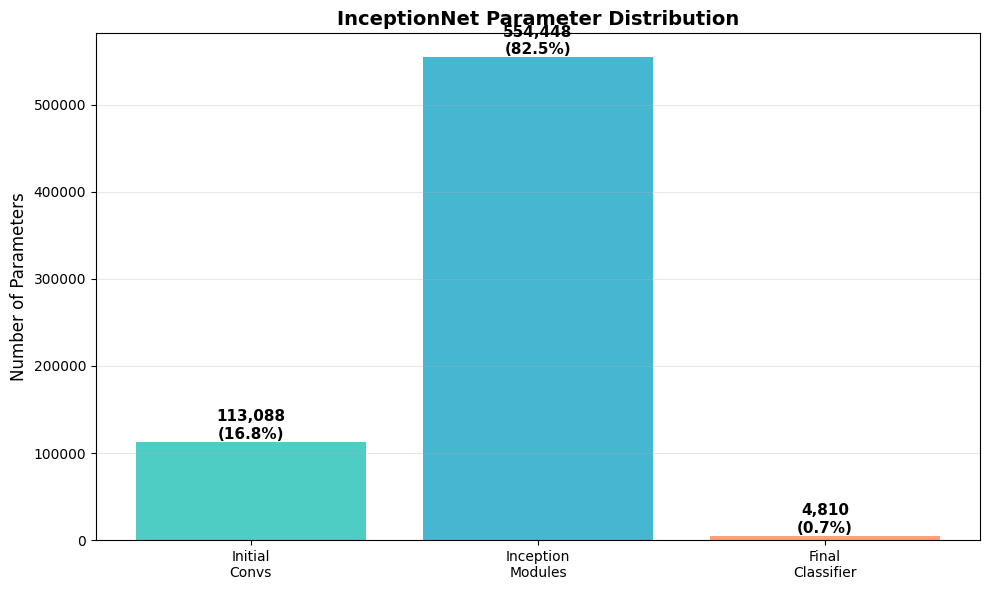

In [14]:
# Count parameters by component
initial_conv = sum(p.numel() for name, p in model.named_parameters() 
                   if 'conv1' in name or 'conv2' in name)
inception_params = sum(p.numel() for name, p in model.named_parameters() 
                       if 'inception' in name)
fc_params = sum(p.numel() for name, p in model.named_parameters() 
                if 'fc' in name)
total = initial_conv + inception_params + fc_params

print(f"InceptionNet Parameter Distribution:")
print(f"  Initial convs:       {initial_conv:>10,} ({100*initial_conv/total:>5.1f}%)")
print(f"  Inception modules:   {inception_params:>10,} ({100*inception_params/total:>5.1f}%)")
print(f"  Final classifier:    {fc_params:>10,} ({100*fc_params/total:>5.1f}%)")
print(f"  Total:               {total:>10,}")
print(f"\n✅ Only {100*fc_params/total:.1f}% in FC layer thanks to Global Average Pooling!")
print(f"   (Compare to VGG's ~80% in FC layers)")

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
components = ['Initial\nConvs', 'Inception\nModules', 'Final\nClassifier']
params = [initial_conv, inception_params, fc_params]
colors = ['#4ECDC4', '#45B7D1', '#FFA07A']

bars = ax.bar(components, params, color=colors)
ax.set_ylabel('Number of Parameters', fontsize=12)
ax.set_title('InceptionNet Parameter Distribution', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

for bar, param in zip(bars, params):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(param):,}\n({100*param/total:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Training

### Define training utilities

In [ ]:
from tqdm.auto import tqdm

In [15]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(train_loader, desc='Training')
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        pbar.set_postfix({'loss': f'{running_loss/len(pbar):.3f}', 
                         'acc': f'{100.*correct/total:.2f}%'})
    
    return running_loss / len(train_loader), 100. * correct / total

def evaluate(model, test_loader, criterion, device):
    """Evaluate on test set."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc='Evaluating'):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    return running_loss / len(test_loader), 100. * correct / total

### Train the model

In [16]:
# Initialize model
model = InceptionNet().to(device)

# Training configuration
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                       factor=0.5, patience=3)

# Training history
history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

# Training loop
epochs = 15
for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")
    
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    
    scheduler.step(test_loss)
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)
    
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")


Epoch 1/15


Training:   0%|          | 0/391 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/79 [00:00<?, ?it/s]

Train Loss: 1.3730 | Train Acc: 49.58%
Test Loss: 1.6071 | Test Acc: 48.84%

Epoch 2/15


Training:   0%|          | 0/391 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/79 [00:00<?, ?it/s]

Train Loss: 0.4003 | Train Acc: 86.16%
Test Loss: 0.5404 | Test Acc: 83.15%

Epoch 15/15


Training:   0%|          | 0/391 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/79 [00:00<?, ?it/s]

Train Loss: 0.3895 | Train Acc: 86.53%
Test Loss: 0.5573 | Test Acc: 82.01%


## 7. Results and Analysis

### Plot training curves

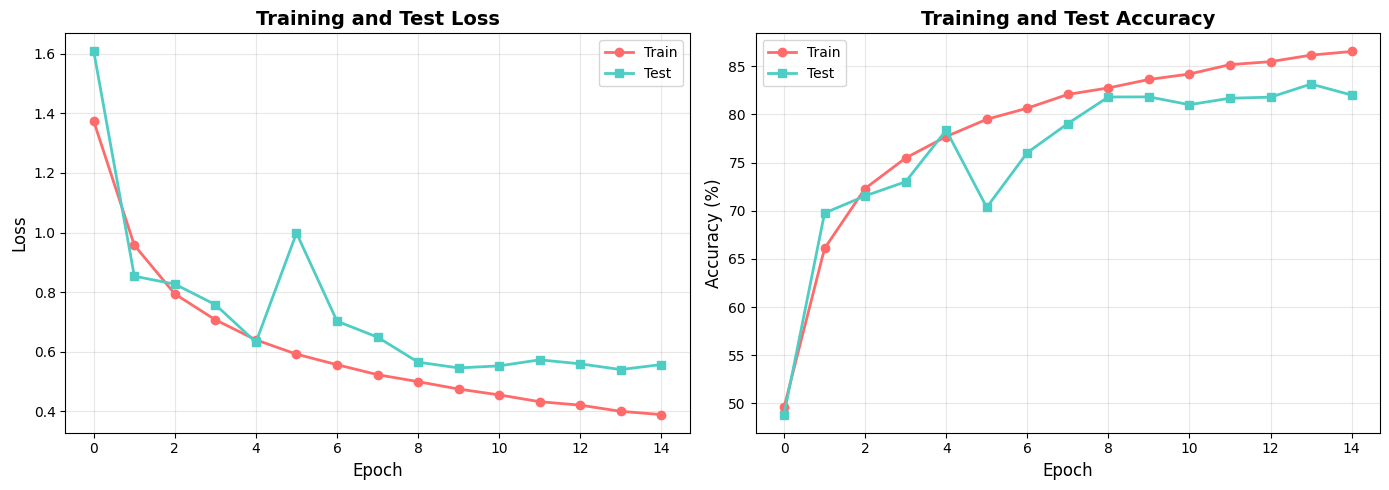


Final Results:
  Train Accuracy: 86.53%
  Test Accuracy: 82.01%
  Overfitting Gap: 4.52%


In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
ax1.plot(history['train_loss'], label='Train', marker='o', linewidth=2, color='#FF6B6B')
ax1.plot(history['test_loss'], label='Test', marker='s', linewidth=2, color='#4ECDC4')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training and Test Loss', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy curves
ax2.plot(history['train_acc'], label='Train', marker='o', linewidth=2, color='#FF6B6B')
ax2.plot(history['test_acc'], label='Test', marker='s', linewidth=2, color='#4ECDC4')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Training and Test Accuracy', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal Results:")
print(f"  Train Accuracy: {history['train_acc'][-1]:.2f}%")
print(f"  Test Accuracy: {history['test_acc'][-1]:.2f}%")
print(f"  Overfitting Gap: {history['train_acc'][-1] - history['test_acc'][-1]:.2f}%")

## 8. The Remaining Challenge: Depth Limits

Inception is efficient and powerful, but even it has limits.

### The Problem: Vanishing Gradients in Very Deep Networks

Despite all innovations (ReLU, BatchNorm, smart architectures), there's still a fundamental issue with depth.

In [18]:
print("The Depth Paradox:\n")
print("Observed phenomenon (2015):")
print("  • 20-layer network: Good performance")
print("  • 56-layer network: WORSE performance")
print("  • Not overfitting - training error also higher!")
print("\n❓ Why? The network should at worst learn the identity...")
print("\nThe degradation problem:")
print("  • Gradients become very small in early layers")
print("  • Even with ReLU and BatchNorm")
print("  • Network struggles to learn identity mappings")
print("  • Deeper ≠ better (counterintuitive!)")
print("\n⚠️  Neither Inception nor VGG could go beyond ~20 layers effectively")

The Depth Paradox:

Observed phenomenon (2015):
  • 20-layer network: Good performance
  • 56-layer network: WORSE performance
  • Not overfitting - training error also higher!

❓ Why? The network should at worst learn the identity...

The degradation problem:
  • Gradients become very small in early layers
  • Even with ReLU and BatchNorm
  • Network struggles to learn identity mappings
  • Deeper ≠ better (counterintuitive!)

⚠️  Neither Inception nor VGG could go beyond ~20 layers effectively


### Visualize the degradation problem

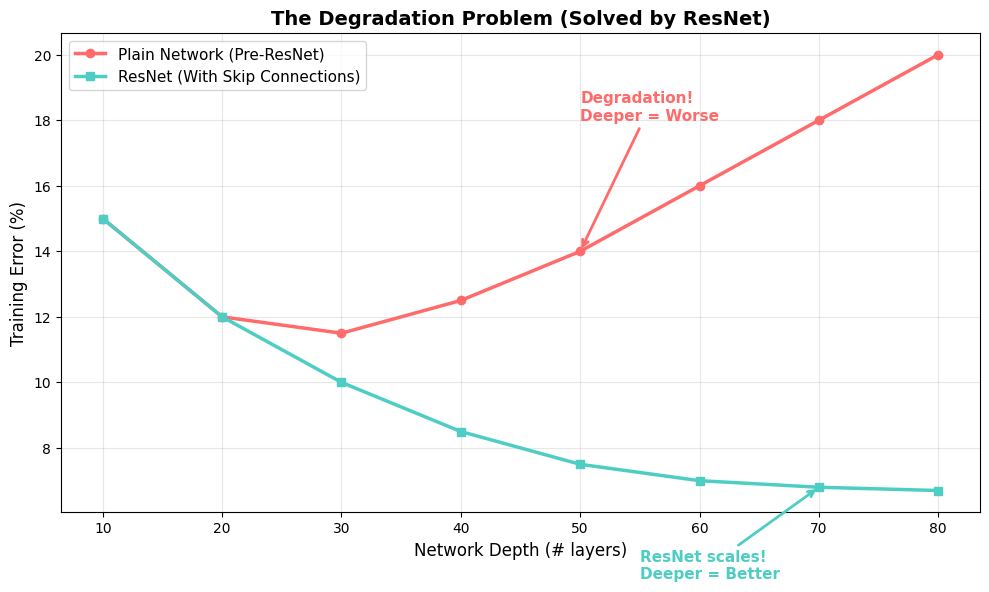


💡 This plot shows the key problem ResNet solved:
   Plain networks degrade after ~20 layers
   ResNet can scale to 100+ layers and keep improving


In [19]:
# Simulate the degradation problem
fig, ax = plt.subplots(figsize=(10, 6))

# Hypothetical training error vs depth (before ResNet)
depths = [10, 20, 30, 40, 50, 60, 70, 80]
plain_error = [15, 12, 11.5, 12.5, 14, 16, 18, 20]  # Error increases!
resnet_error = [15, 12, 10, 8.5, 7.5, 7, 6.8, 6.7]  # Error decreases

ax.plot(depths, plain_error, marker='o', linewidth=2.5, 
        label='Plain Network (Pre-ResNet)', color='#FF6B6B')
ax.plot(depths, resnet_error, marker='s', linewidth=2.5,
        label='ResNet (With Skip Connections)', color='#4ECDC4')

ax.set_xlabel('Network Depth (# layers)', fontsize=12)
ax.set_ylabel('Training Error (%)', fontsize=12)
ax.set_title('The Degradation Problem (Solved by ResNet)', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Annotate the problem
ax.annotate('Degradation!\nDeeper = Worse', xy=(50, 14), xytext=(50, 18),
            arrowprops=dict(arrowstyle='->', lw=2, color='#FF6B6B'),
            fontsize=11, color='#FF6B6B', fontweight='bold')

ax.annotate('ResNet scales!\nDeeper = Better', xy=(70, 6.8), xytext=(55, 4),
            arrowprops=dict(arrowstyle='->', lw=2, color='#4ECDC4'),
            fontsize=11, color='#4ECDC4', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💡 This plot shows the key problem ResNet solved:")
print("   Plain networks degrade after ~20 layers")
print("   ResNet can scale to 100+ layers and keep improving")

### The ResNet Solution: Skip Connections

**Idea:** Don't make layers learn the full mapping - let them learn the **residual**.

Instead of learning: `H(x) = desired_output`

Learn the residual: `F(x) = desired_output - x`, then output `F(x) + x`

In [20]:
print("ResNet's Insight:\n")
print("Plain layer:")
print("  H(x) = ReLU(Conv(ReLU(Conv(x))))")
print("  Must learn everything from scratch")
print("  Hard to learn identity when beneficial")
print("\nResidual block:")
print("  H(x) = F(x) + x")
print("  where F(x) = ReLU(Conv(ReLU(Conv(x))))")
print("  \nBenefits:")
print("  ✅ If identity is optimal, F(x) just learns zeros")
print("  ✅ Gradients flow directly through skip connections")
print("  ✅ Each layer refines rather than rebuilds")
print("  ✅ Enables 100+ layer networks!")
print("\n🏆 Result: ResNet-152 won ImageNet 2015")
print("   3.57% error (better than human-level 5%)")

ResNet's Insight:

Plain layer:
  H(x) = ReLU(Conv(ReLU(Conv(x))))
  Must learn everything from scratch
  Hard to learn identity when beneficial

Residual block:
  H(x) = F(x) + x
  where F(x) = ReLU(Conv(ReLU(Conv(x))))
  
Benefits:
  ✅ If identity is optimal, F(x) just learns zeros
  ✅ Gradients flow directly through skip connections
  ✅ Each layer refines rather than rebuilds
  ✅ Enables 100+ layer networks!

🏆 Result: ResNet-152 won ImageNet 2015
   3.57% error (better than human-level 5%)


## 9. Summary: The Complete CNN Evolution

### The Journey from LeNet to ResNet

```
LeNet (1998) - The Pioneer
  ✅ Proved CNNs work
  ❌ Too shallow, too few filters, tanh activation
  
         ↓  Innovation: Depth + ReLU + Dropout

AlexNet (2012) - The Breakthrough  
  ✅ Deep learning revolution, ImageNet victory
  ❌ Large filters, heterogeneous design, FC-heavy
  
         ↓  Innovation: Uniform 3×3 architecture

VGG (2014) - The Systematic Approach
  ✅ Elegant uniform design, systematic depth
  ❌ Massive parameters, single-scale, compute-heavy
  
         ↓  Innovation: Multi-scale + efficiency

Inception (2014) - The Efficient Design
  ✅ Multi-scale, 1×1 bottlenecks, no FC layers
  ❌ Can't scale beyond ~20 layers (degradation)
  
         ↓  Innovation: Skip connections

ResNet (2015) - The Depth Revolution
  ✅ 100+ layers, residual learning, superhuman performance
  🎯 Foundation for modern architectures
```

### Key Lessons from CNN Evolution

| Lesson | Impact |
|--------|--------|
| **1. Depth matters** | LeNet→AlexNet showed more layers learn better features |
| **2. ReLU enables depth** | Faster training, no saturation |
| **3. Small filters are efficient** | VGG proved 3×3 stacking beats large filters |
| **4. Multi-scale is natural** | Inception showed parallel paths work better |
| **5. Efficiency matters** | 1×1 bottlenecks + GAP reduce parameters massively |
| **6. Shortcuts enable scale** | ResNet skip connections solve degradation |

### Modern Impact

Every modern CNN architecture builds on these principles:

- **EfficientNet**: Compound scaling of depth/width/resolution
- **MobileNet**: Depthwise separable convs (extreme efficiency)
- **ConvNeXt**: Modernized CNNs competitive with Transformers
- **Vision Transformers**: Even attention mechanisms use these ideas

---

### What's Next?

The **residual-connections** notebook dives deep into:
- Mathematical intuition for why skip connections work
- Different residual block designs
- Training very deep networks (50, 101, 152 layers)
- How ResNets changed everything

---

### Final Thought

CNN evolution shows that **progress comes from understanding limitations**. Each architecture:
1. Solved specific problems from predecessors
2. Revealed new limitations
3. Inspired the next breakthrough

This pattern continues today. Understanding *why* each innovation mattered is more valuable than memorizing architectures.